In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
df = pd.read_csv("nba_final_dataset.csv")
# Handle missing values

df["FG%"] = df["FG%"].fillna(df["FG%"].mean())
# Convert MP from mm:ss to float minutes

def convert_mp(mp):
    minutes, seconds = mp.split(":")
    return int(minutes) + int(seconds) / 60

df["MP"] = df["MP"].apply(convert_mp)

# Encoding

encoder = LabelEncoder()

df["Team"] = encoder.fit_transform(df["Team"])
df["Player"] = encoder.fit_transform(df["Player"])

# Scaling


scaler = StandardScaler()

numeric_cols = [
    "MP", "PTS", "TRB", "AST",
    "FGA", "FG%", "STL", "TOV"
]

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print(df.head())

print(df.info())

df.to_csv("nba_preprocessed.csv", index=False)

print("REAL preprocessing completed successfully")

   Game_Date  Team  Player        MP       PTS       TRB       AST       FGA  \
0   20251101    25     113  1.830533  2.048740 -0.015845  0.208047  1.805808   
1   20251101    25     494  1.582544  2.273030 -0.015845 -0.177476  1.470112   
2   20251101    25     117  1.418808  1.488015  0.283463  1.750142  0.798719   
3   20251101    25     127  1.404501  1.488015  2.677930  1.364618  0.798719   
4   20251101    25     143 -1.636546 -0.979176 -0.913770 -0.948523 -1.215461   

        FG%      STL       TOV  
0  0.293646 -0.78218  0.508793  
1  0.059664  0.22981 -0.910007  
2  0.672273  1.24180  1.218193  
3  0.672273  0.22981  1.218193  
4  2.310152 -0.78218 -0.910007  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9067 entries, 0 to 9066
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Game_Date  9067 non-null   int64  
 1   Team       9067 non-null   int64  
 2   Player     9067 non-null   int64  
 3   MP       

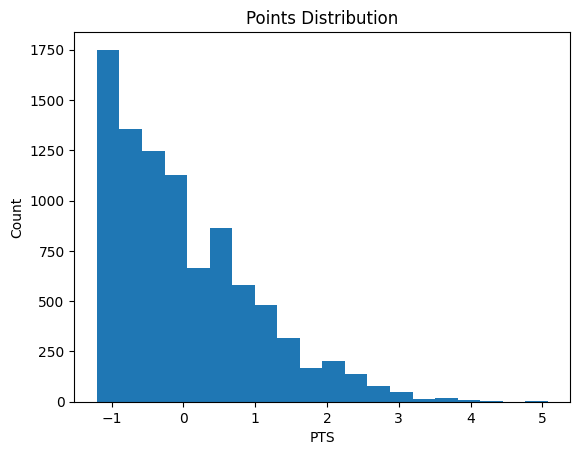

In [ ]:
import matplotlib.pyplot as plt

# histogram for points
plt.hist(df["PTS"], bins=20)

plt.title("Points Distribution")
plt.xlabel("PTS")
plt.ylabel("Count")

plt.show()

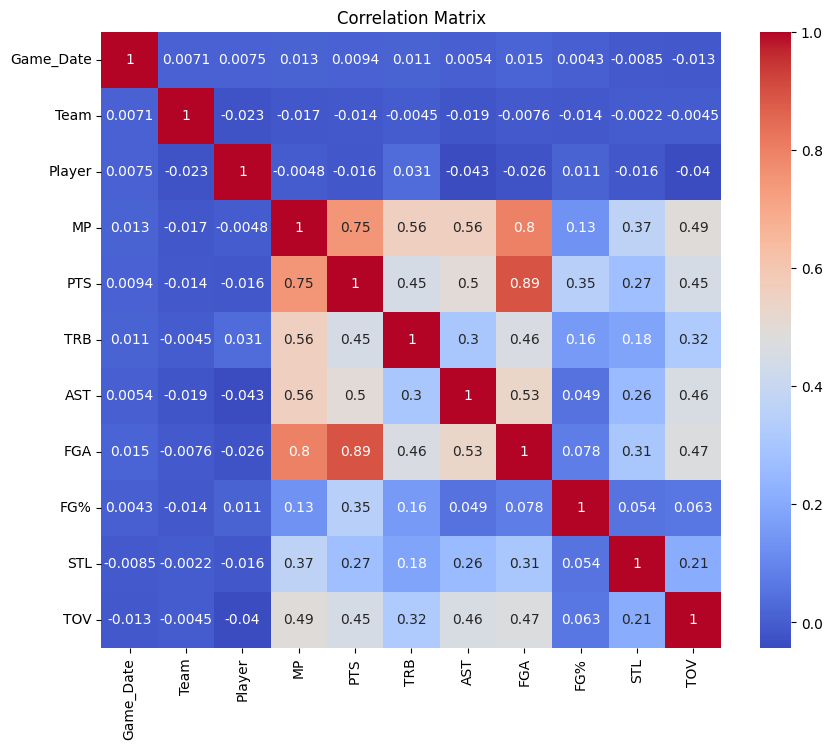

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# correlation matrix
corr = df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Features
X = df.drop("PTS", axis=1)

# Target
y = df["PTS"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.18154448246460672
R2 Score: 0.9329554605037833


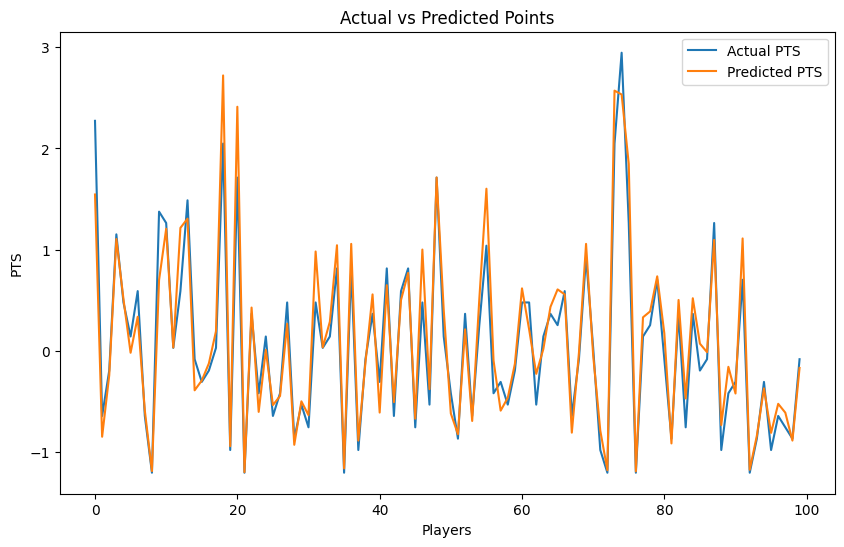

In [10]:
import matplotlib.pyplot as plt

# plot real vs predicted
plt.figure(figsize=(10,6))

plt.plot(y_test.values[:100], label="Actual PTS")
plt.plot(predictions[:100], label="Predicted PTS")

plt.legend()

plt.title("Actual vs Predicted Points")

plt.xlabel("Players")
plt.ylabel("PTS")

plt.show()

In [11]:
import pandas as pd

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

     Feature  Importance
6        FGA    0.787424
7        FG%    0.152424
3         MP    0.014691
2     Player    0.009840
1       Team    0.007709
0  Game_Date    0.007595
4        TRB    0.006631
5        AST    0.006057
9        TOV    0.004602
8        STL    0.003025


In [12]:
print("Final Model Evaluation")
print("----------------------")
print("Model: Random Forest Regressor")
print("Target Variable: PTS")
print("Mean Absolute Error (MAE):", mae)
print("R2 Score:", r2)

print("\nMost Important Features:")
print(feature_importance.head())

Final Model Evaluation
----------------------
Model: Random Forest Regressor
Target Variable: PTS
Mean Absolute Error (MAE): 0.18154448246460672
R2 Score: 0.9329554605037833

Most Important Features:
  Feature  Importance
6     FGA    0.787424
7     FG%    0.152424
3      MP    0.014691
2  Player    0.009840
1    Team    0.007709
